# AI Tutorials

Here we present examples on how MieNet's ai functionalities can be used.


## Using ANN Predictions

ANN predictions provide fast and accurate opacity calculations. To see how to make your own training set and train a model, see instructions after this example.

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


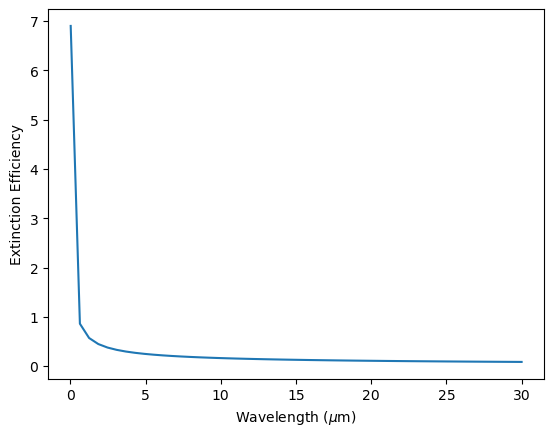

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mienet import MieNet

# determine model inputs
species =  ['Fe', 'Mg2SiO4']
wavelength_range = np.linspace(0.02, 30, 50)  # microns, within range of model
radius_range = np.linspace(0.01, 0.01, 50)  # microns, within range of model
vmrs = {
    'Fe': 0.5 * np.ones_like(radius_range),
    'Mg2SiO4': 0.5 * np.ones_like(radius_range)}

# name of model in config.yaml file
config_name = 'TUTORIAL_MODEL'

# initialize MieNet again after adding AI model
ma = MieNet(load_ai_model = config_name, default_data_location = 'tutorial_files/')
    # set load_ai_model = name of desired model in config file, default is 'all' and loads every model

# predict efficiencies
qext, qsca, asym = ma.ai_efficiencies(wavelength_range, radius_range, vmrs)

# plot results
plt.figure()
plt.plot(wavelength_range, np.mean(qext, axis=0))
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Extinction Efficiency')
plt.show()

## Making your own AI Model
Here we present information on how to use MieNet to train your own ANN.

### Step 1: Creating a training set

Training set inputs:
- wavelength sample
- cloud particle size sample
- volume mixing ratios

The smaller your wavelengths and particle sizes are and the smaller amount of materials in your mixture, the smaller your training set will need to be. The total training set size is equal to (number of wavelengths) * (number of particle sizes). Wavelengths and volume mixing ratios will be randomly sampled, and particle sizes are sampled in a fixed grid. MieNet's function to produce a training set saves it as an xarray.Dataset, and allows users to stop and continue generating data until the dataset is full:

In [3]:
import numpy as np
from mienet import MieNet

# import mienet
ma = MieNet(default_data_location = 'tutorial_files/')
    # default option is default_data_location = None to save in data folder
    # OR set default_data_location = 'path/to/your/folder/' for specific folder

# determine file name, materials, and mixing theory
file = 'tutorial_training_set'
species = ['Fe', 'Mg2SiO4']
mixing_theory = 'LLL' # optional, either LLL (default) or Bruggeman

# determine particle size & wavelength sampling
radii_sampling = (0.001, 0.01, 5) # (min particle size, max particle size, number of radii points)
wavelength_sampling = (0.01, 50, 20) # (min wavelength, max wavelength, number of wavelength points)
    # number of radii points and wavelength points are low for tutorial and small ranges, 1000+ recommended

# generate dataset
ma.generate_training_set(file, species, wavelength_sampling, radii_sampling, mixing_theory)

### Step 2: Training a neural network

MieNet uses [TensorFlow](https://www.tensorflow.org/) to train and save AI models. To build a neural network and train it with MieNet, the following is used:
- Training set
- Model parameters

Model parameters are not required, but there are several parameters available to customize your model. To train an AI model, use the following function:

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - asymmetry_loss: 0.0870 - asymmetry_mae: 0.2471 - extinction_loss: 1.5915 - extinction_mae: 1.1208 - loss: 2.0694 - scattering_loss: 0.3890 - scattering_mae: 0.2690 - val_asymmetry_loss: 0.0762 - val_asymmetry_mae: 0.2708 - val_extinction_loss: 2.0408 - val_extinction_mae: 1.4034 - val_loss: 2.1173 - val_scattering_loss: 2.7071e-04 - val_scattering_mae: 0.0152
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - asymmetry_loss: 0.0809 - asymmetry_mae: 0.2386 - extinction_loss: 1.3679 - extinction_mae: 1.0331 - loss: 1.8238 - scattering_loss: 0.3830 - scattering_mae: 0.2695 - val_asymmetry_loss: 0.0669 - val_asymmetry_mae: 0.2531 - val_extinction_loss: 1.5824 - val_extinction_mae: 1.2300 - val_loss: 1.6504 - val_scattering_loss: 0.0011 - val_scattering_mae: 0.0327
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - asymmetry_loss: 0.0752 - asymmetry_mae: 0.2268 - extinction_loss: 0.9965 - extinction_mae: 0.8899 - loss: 1.4563 - scattering_l

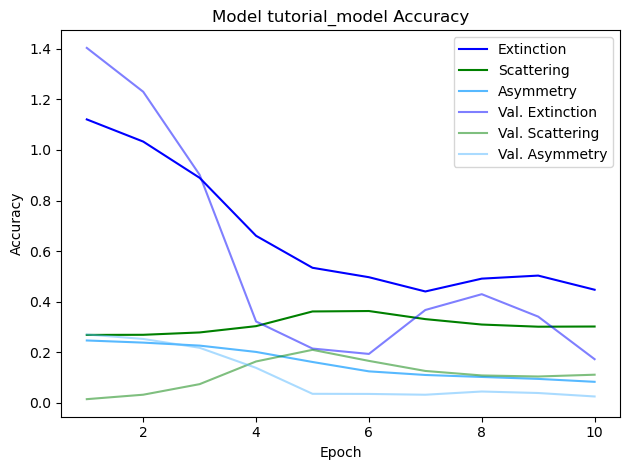

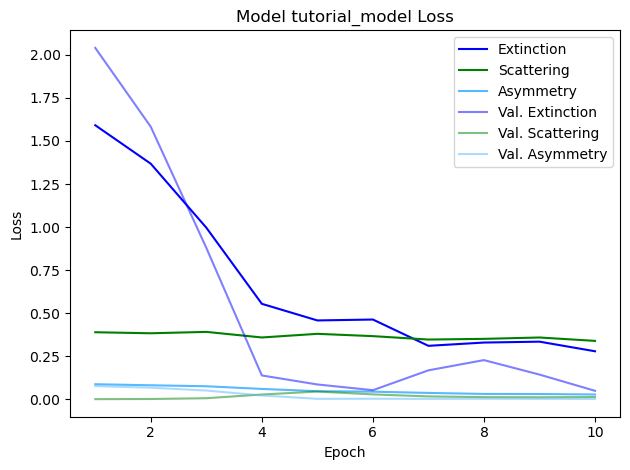

In [4]:
import xarray as xr

ma = MieNet(default_data_location = 'tutorial_files/')

# set model parameters
model_params = {'name': 'tutorial_model', # file name of AI model
                'layers': 6} # number of hidden layers
    # other optional parameters: nodes, activation_function, optimizer, loss, metrics, batch_size, epochs, log_wavelength, log_particle_size, log_extinction, log_scattering

# train your model
ma.train_ai_model(file, model_params, plot_training = True) # plot_training is optional, default is no plotting